# Code Assistant Agent: Measure & Optimize the Cost of a Multi-Agent Code Assistant

**L400 hands-on lab. About 120 minutes.**

## Lab overview

Agentic applications drive significant model and service costs. A single user question can fan out
into repeated coordinator model calls, sub-agent calls, retrieval queries, and thousands of hidden
reasoning tokens, so cost per query climbs quickly, and teams often take agents to production
without ever knowing that number. Just as important, the cheapest configuration is rarely the right
one: aggressive cost cutting quietly degrades answer quality. The engineering skill this lab teaches
is finding an economical, optimized configuration that still maintains high answer quality.

Here is your scenario. Your team operates **Code Assistant Agent**, an internal developer assistant
built with the **Agent Development Kit (ADK)**. For each coding question or error message, a
**Coordinator** agent consults a **DocsAgent** (your team's internal engineering docs and runbooks,
served by managed **Agent Search**) and a **CommunityAgent** (prior Stack Overflow discussions in a
local vector store), then synthesizes one cited answer. The assistant answers well, but nobody has
measured what each answer costs. Your assignment: measure it, then optimize it, **without giving up
answer quality**.

### Learning objectives

By the end of this lab, you will be able to:

1. Apply the three major optimization levers to an agentic application (**model selection &
   tiering**, **context caching**, and **reasoning & retrieval token reduction**), re-measuring
   cost per query after each change.
2. Balance cost against quality: score every configuration, keep quality at or above a quality floor, and
   distinguish the free wins from the changes that trade answer quality for savings.
3. Break an agentic application's bill into its components (input, cached, output, and reasoning
   "thought" tokens; per-token embeddings; per-query managed retrieval) and identify which
   component drives the total, so you know which lever to pull.

You finish with a graded **final challenge**: hit a cost-per-query budget while holding answer quality at or
above a quality floor (a minimum passing score), scored on held-out queries you never optimized against.

### How the lab works

The method throughout is: **measure, change one lever, measure again**. Part 0 sets up the
environment and the measurement loop. The full cost model is defined in this notebook, and an
imported usage ledger prices every billable event against it. You cannot optimize what you cannot
attribute. Parts 1 to 5 measure the baseline and apply the levers, one per part, with a bonus
semantic-cache demo. Part 6 is the graded final challenge, required to complete the lab. One control is
pinned throughout: **thinking effort stays at HIGH** (the Pro coordinator's documented default) for
every configuration until Part 4 turns that dial deliberately. That keeps model comparisons apples to
apples. The agent wiring, retrieval, ledger container, and Agent Search
plumbing stay in the imported `code_assistant` package.

**Prerequisites:** a Google Cloud project with Gemini Enterprise Agent Platform enabled, plus the
packages from the install cell. Latency is deliberately not scored in this lab; shared
lab-environment API latency is too noisy to grade fairly.

### Architecture

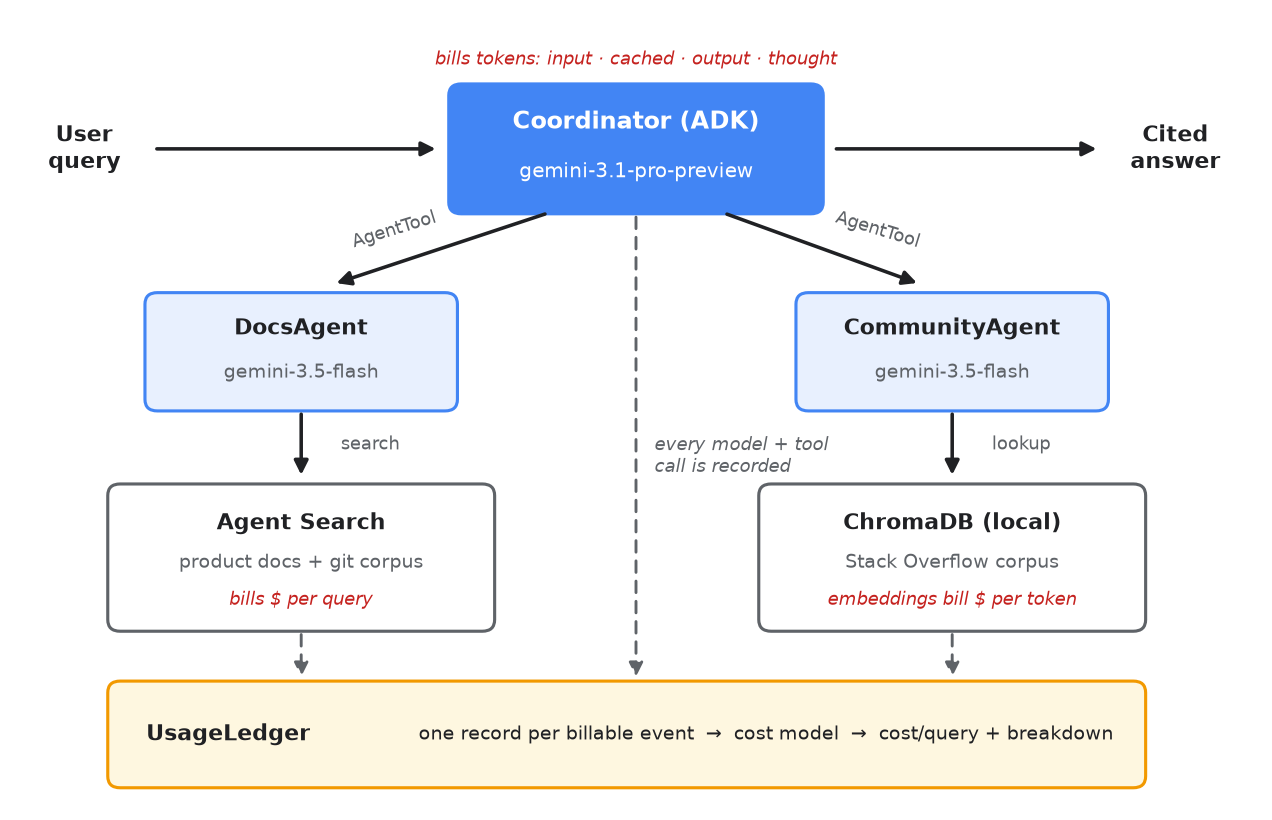

One query fans out into several billable events. The Coordinator plans and synthesizes (Pro-priced
tokens, including its hidden "thought" tokens), each consulted sub-agent spends Flash-priced tokens,
DocsAgent lookups bill per Agent Search query, and CommunityAgent lookups bill per embedded
token. The dashed path is the measurement loop that powers the lab: every one of those events lands
in the UsageLedger, which the cost model turns into cost per query and a per-component breakdown.

UsageLedger is a small class written for this lab, not a Google Cloud product. The pattern is the
takeaway: attribute every billable event. Production systems get the same data from billing export
or logging.

### The data in this lab

| File | Rows | Where it runs | Role |
|---|---|---|---|
| `assets/docs.jsonl` | 20 | **Agent Search** (managed data store + engine) | DocsAgent's corpus (the document set it searches): notes written in the style of official documentation, covering ~20 common Python errors; each lookup bills per search query |
| `assets/stackoverflow.jsonl` | 20 | **ChromaDB** (local, in-memory) | CommunityAgent's corpus: community Q&A on the same errors; lookups bill per embedded token |
| `assets/eval_dataset.jsonl` | 15 | loaded as `dataset` | The queries measured in Parts 1 to 5, easy to hard multi-part, each with a **reference answer** the quality judge scores against |
| `assets/eval_holdout.jsonl` | 16 | loaded as `holdout` | Final-challenge grading only; you never optimize against these |

The two corpora cover the same error scenarios in two voices (official docs vs accepted community
answers), which is what lets the Coordinator cite its sources, and the two retrieval backends
deliberately have different cost shapes. All rows are small, hand-authored synthetic data sized for
a lab.

## Part 0: Setup, the cost model, and the ledger

In [2]:
# Install the lab's dependencies (takes a minute on a fresh environment):
%pip install -q google-adk==2.3.0 "google-cloud-aiplatform[evaluation]>=1.158.0" "google-genai>=2.10.0" "chromadb>=1.5.9" "google-cloud-discoveryengine>=0.20.0" pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Restart the kernel so the freshly installed packages load. (Automated test runs set
# IS_TESTING to skip the restart; the same convention Google's sample notebooks use.)
import os
if not os.getenv("IS_TESTING"):
    import IPython
    IPython.Application.instance().kernel.do_shutdown(True)

/var/tmp/ipykernel_5201/713809943.py:6: DeprecationWarning: `IPython.Application` is only a re-export of `traitlets.config.application.Application`; import it from traitlets directly. Accessing it here triggers an import of `IPython.core.application`, which is no longer imported when IPython is -- import that module explicitly if you rely on that import happening, in particular if you also rely on other submodules being transitively imported as a side effect.
  IPython.Application.instance().kernel.do_shutdown(True)


**Wait for the kernel to finish restarting**, then continue from the next cell. When you rerun the
notebook later in the lab, skip the install and restart cells; they are one-time setup.

### Set your project

The next cell reads your lab project ID from the environment, so you can run it as is.
The guard stops the notebook early if no project is set.

In [1]:
import os

# Qwiklabs sets GOOGLE_CLOUD_PROJECT on the Workbench instance, so this cell needs no
# edits in the lab environment. Outside it, replace the fallback with your project ID.
PROJECT_ID =!(gcloud config get-value project)
PROJECT_ID = PROJECT_ID[0]
PROJECT = os.environ.get("GOOGLE_CLOUD_PROJECT", PROJECT_ID)
LOCATION = "global"           # the Gemini 3 family serves from the global endpoint
EVAL_LOCATION = "us-central1" # the Gen AI evaluation service is regional

In [2]:
import os, warnings
warnings.filterwarnings("ignore")     # keep saved outputs readable (experimental-SDK warnings)
os.environ["TQDM_DISABLE"] = "1"      # hide eval-service progress bars in outputs
import logging
logging.getLogger("google_adk").setLevel(logging.CRITICAL)  # tool misfires print one warning line, not a traceback

os.environ.update(GOOGLE_GENAI_USE_VERTEXAI="TRUE",
                  GOOGLE_CLOUD_PROJECT=PROJECT, GOOGLE_CLOUD_LOCATION=LOCATION)

# Model config: the Gemini 3 family end to end (a Pro-tier coordinator, Flash sub-agents).
MODELS = {"coordinator": "gemini-3.1-pro-preview", "docs": "gemini-3.5-flash",
          "community": "gemini-3.5-flash", "embedding": "gemini-embedding-001"}
THINKING = "HIGH"   # pinned reasoning effort (3.1 Pro's documented default) so comparisons are apples to apples

# Plumbing (ADK agent wiring, ChromaDB retrieval, Agent Search, the usage ledger,
# data loading, the eval-service wrapper) lives in the package:
from code_assistant.agents import build_code_assistant, answer_query
from code_assistant.retrieval import build_index, embed_texts
from code_assistant.ledger import UsageLedger
from code_assistant.display import show_result, show_verdict, show_target
from code_assistant.data import load_jsonl
from code_assistant.quality import run_quality_eval
from code_assistant import vais
print("ready; project:", PROJECT)

ready; project: qwiklabs-gcp-04-defacf1d0ff9


### The cost model

Every billable event maps to dollars here. The rates are the **published list prices as of July 2026**,
quoted per 1M tokens exactly as the pricing pages state them
(global endpoint, at or below 200k context, online requests, Agent Search Standard Edition). Prices
change; confirm against the live [model pricing page](https://cloud.google.com/vertex-ai/generative-ai/pricing)
and [Agent Search pricing](https://cloud.google.com/generative-ai-app-builder/pricing). 

In [3]:
# Published list prices, July 2026 (global endpoint, <=200k context, online requests,
# Agent Search Standard Edition). Rates quoted the way the pricing pages state them.
PRICING = {
    # USD per 1M tokens:              input        cached       output (thoughts bill as output)
    "gemini-3.1-pro-preview": {"input": 2.00, "cached": 0.20, "output": 12.00},
    "gemini-3.5-flash":       {"input": 1.50, "cached": 0.15, "output":  9.00},
    "gemini-3.1-flash-lite":         {"input": 0.25, "cached": 0.025, "output": 1.50},
    "gemini-2.5-pro":         {"input": 1.25, "cached": 0.13, "output": 10.00},
    "gemini-2.5-flash":       {"input": 0.30, "cached": 0.03, "output":  2.50},
    "embedding":  {"per_1m_tokens": 0.15},    # gemini-embedding-001: $0.00015 per 1k input tokens
    "vais_query": {"per_1k_queries": 1.50},   # Agent Search queries, Standard Edition
}

def cost_of(record):
    "USD for one billable event. Thought (reasoning) tokens bill at the output rate."
    ct = record.get("call_type")
    if ct == "model":
        p = PRICING[record["model"]]
        out = record.get("output_tokens", 0) + record.get("thought_tokens", 0)
        return round((record.get("input_tokens", 0) * p["input"]
                      + record.get("cached_tokens", 0) * p["cached"]
                      + out * p["output"]) / 1e6, 12)
    if ct == "embedding":
        return round(record.get("embed_tokens", 0) * PRICING["embedding"]["per_1m_tokens"] / 1e6, 12)
    if ct == "retrieval":
        return round(record.get("retrieval_queries", 0) * PRICING["vais_query"]["per_1k_queries"] / 1e3, 12)
    return 0.0

# Sanity checks (this is the lab's cost contract). Check the first assert's arithmetic yourself:
# 1,000 input tokens at $1.50/1M is $0.0015; 150 output-side tokens at $9/1M is $0.00135.
assert cost_of({"call_type": "model", "model": "gemini-3.5-flash",
                "input_tokens": 1000, "output_tokens": 100, "thought_tokens": 50}) \
       == round((1000*1.50 + 150*9.00) / 1e6, 12)              # thoughts counted as output
assert cost_of({"call_type": "embedding", "model": "embedding", "embed_tokens": 1000}) == round(1000*0.15/1e6, 12)
assert cost_of({"call_type": "retrieval", "model": "vais_query", "retrieval_queries": 3}) == round(3*1.50/1e3, 12)
print("cost model OK")

cost model OK


### Scoring quality and the measurement loop

Quality is scored by an **LLM judge** (an autorater): for every answer, a judge model reads the
question, the agent's answer, and the dataset's **reference answer**. It then assigns a 1 to 5 rating
against a correctness rubric **we define ourselves** in `code_assistant/quality.py`; the next cell
prints that exact quality bar. We normalize the mean rating to [0,1]. Two properties to keep in mind:
the judge is itself a model, so scores vary a little run to run (roughly +/-0.1 on 15 queries),
and judge calls are billable API calls too; they are measurement overhead, deliberately not part of
the agent's ledger.

`measure(...)` ties the loop together: run a query set through the agent, let the ledger accumulate
cost, score quality, and return one scorecard row.

In [4]:
# The exact quality bar the judge applies (defined in code_assistant/quality.py):
from code_assistant.quality import CRITERIA, RATING_RUBRIC
print("Criteria the judge checks:")
for name, desc in CRITERIA.items():
    print(f"  {name}: {desc}")
print("\nRating rubric (1-5, normalized to [0,1]):")
for score in sorted(RATING_RUBRIC, reverse=True):
    print(f"  {score}: {RATING_RUBRIC[score]}")

Criteria the judge checks:
  correctness: The response's technical claims and recommended fixes agree with the reference answer. It contains no claim that contradicts the reference.
  completeness: The response covers the essential points of the reference answer; for multi-part questions, it addresses every part.

Rating rubric (1-5, normalized to [0,1]):
  5: Fully correct and complete: agrees with the reference on all key points and covers them all.
  4: Correct with minor omissions: agrees with the reference but misses a small detail.
  3: Partially correct: covers some key points of the reference but misses others.
  2: Mostly incomplete or contains an incorrect claim on a key point.
  1: Wrong: contradicts the reference or fails to answer the question.


In [5]:
import time

def measure(coordinator, items, qid_holder, ledger, project, location, label):
    ledger.reset()
    answers = []
    for item in items:
        # one retry per query on top of the SDK's own retries (every client here enables
        # HttpRetryOptions: 5 attempts, exponential backoff); this net catches run-level
        # failures ADK would otherwise swallow
        for attempt in (1, 2):
            try:
                ans = answer_query(coordinator, item["query"], str(item["id"]), qid_holder)
                if not ans.strip():
                    raise RuntimeError("agent returned an empty answer")
                break
            except Exception as e:
                if attempt == 2:
                    # A query that fails twice would poison this configuration's numbers
                    # (an empty answer scores the rubric minimum and its cost is partial),
                    # so stop loudly instead of recording a bad row.
                    raise RuntimeError(f"query {item['id']} failed twice ({e}); re-run this cell") from e
                print(f"[run warning] query {item['id']}: {str(e).splitlines()[0]}; retrying once")
                time.sleep(5)
        answers.append({"query": item["query"], "answer": ans, "reference": item.get("reference", "")})
    quality = run_quality_eval(answers, project, location)
    return {"configuration": label, "cost_per_query": ledger.cost_per_query(),
            "quality": quality, "breakdown": ledger.cost_breakdown()}, answers

scorecard = []   # one row per configuration; re-running a measurement cell replaces its row

def record_result(row):
    "Add a result to the scorecard; a re-run replaces its earlier row in place."
    for i, r in enumerate(scorecard):
        if r["configuration"] == row["configuration"]:
            scorecard[i] = row
            return
    scorecard.append(row)

### Provision retrieval and assemble the agent

The next cell sets up the two retrieval backends: a managed **Agent Search** data store and engine
over the docs corpus for DocsAgent, and a local **ChromaDB** index of Stack Overflow posts for
CommunityAgent. Provisioning Agent Search takes a few minutes the first time; when the engine
already exists, the cell detects it and reuses it in seconds.

It also loads two query sets: a 15-query **dataset** used in Parts 1 to 5, and a 16-query **held-out
set** reserved for the final challenge, so you cannot optimize against the queries that grade you.

One production-hygiene detail is baked into the imported `code_assistant` package: every agent call
runs under a `max_output_tokens` ceiling: 2,048 for the sub-agents, 3,072 for the Coordinator. The
cap counts thinking and answer tokens together. Typical calls for this agent setup and sample
dataset sit far below it: sub-agent calls total a few hundred tokens (they bill no thought tokens),
and Coordinator calls stay under about 1,500 including thoughts. The ceilings bound the cost of an
occasional **unbounded response**, where a reply keeps generating until it reaches the output
limit. An unbounded response is an unbounded bill, so bound what you do not control. (Deliberately
capping the Coordinator's final answer much tighter is a knob you will meet in the final
challenge.)

In [6]:
# First run takes a few minutes (provisioning); later runs detect the engine and reuse it.
VAIS_LOCATION, DS_ID, ENGINE_ID = "global", "code_assistant-docs", "code_assistant-docs-engine"
DOCS_SC = vais.ensure(PROJECT, VAIS_LOCATION, DS_ID, ENGINE_ID, load_jsonl("assets/docs.jsonl"))
print("DocsAgent backend: Agent Search engine", ENGINE_ID)

so      = load_jsonl("assets/stackoverflow.jsonl")
dataset = load_jsonl("assets/eval_dataset.jsonl")    # 15 queries, easy -> hard multi-part
holdout = load_jsonl("assets/eval_holdout.jsonl")    # 16 held-out queries (final challenge only)
community = build_index(so, MODELS["embedding"], PROJECT, LOCATION, name="community")
print("indexed %d Stack Overflow posts into ChromaDB" % len(so))

qid = {"v": "_"}   # mutable holder: the ledger callbacks read the current query id through it,
                   # so one shared reference follows every query
def build(models, thinking_level=THINKING, max_output_tokens=None, top_k=3):
    # fresh ledger per configuration, pricing with the notebook's cost_of; callbacks/tools record into it
    ledger = UsageLedger(cost_of)
    coord = build_code_assistant(models=models, ledger=ledger, qid_holder=qid,
                            project=PROJECT, location=LOCATION,
                            collections={"community": community}, docs_serving_config=DOCS_SC,
                            top_k=top_k, max_output_tokens=max_output_tokens,
                            thinking_level=thinking_level)
    return coord, ledger

  created data store: code_assistant-docs
  imported 20 documents
  created engine: code_assistant-docs-engine
DocsAgent backend: Agent Search engine code_assistant-docs-engine
indexed 20 Stack Overflow posts into ChromaDB


In [7]:
# A sample of the data: one entry from each corpus, then the first three dataset queries with
# the reference answers the quality judge compares against.
# Skim the reference answers now; every quality score in this lab is agreement with them.
import pandas as pd
print("docs corpus:      ", load_jsonl("assets/docs.jsonl")[0]["text"][:100], "...")
print("community corpus: ", so[0]["text"][:100], "...")
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda v: f"{v:.8f}")  # dollars, not scientific notation
pd.DataFrame(dataset)[["id", "query", "reference"]].head(3)

docs corpus:       KeyError is raised when a dictionary lookup with d[key] finds no such key. Use dict.get(key, default ...
community corpus:  Q: Why does my code raise KeyError on dict access? A (accepted, 1.3k votes): the key is not present. ...


,id,query,reference
0,t1,I'm getting a KeyError when reading a value from a dict in Python. How do I fix it?,"KeyError means the key is missing. Use dict.get(key, default) or check 'key in d' before indexin..."
1,t2,pip install said it installed the package but I still get ModuleNotFoundError. Why?,pip and python point to different environments. Use 'python -m pip install' and compare 'which p...
2,t3,I keep hitting IndexError: list index out of range inside a for loop. How do I fix it?,"You index past the end. Iterate directly or with enumerate, or guard with 'if i < len(xs)'; chec..."


### See one query's full cost breakdown

The next cell sends one question through the assembled agent. It prints the synthesized answer, then
displays the ledger: one row per billable event, each agent's model calls, the embedding lookup for
the community search, and the Agent Search query, with the cost of each. Every cost number in the rest of
this lab is a sum over rows like these.

How to read the table: an agent that uses a tool makes **two model calls**, one to decide on the tool
call and one to analyze the tool's results and write its answer, so each sub-agent appears twice and the
Coordinator opens and closes the query. The `embedding` row bills by `embed_tokens` (gemini-embedding-001 prices per input token; some
older embedding models price per character instead), and the `retrieval` row is the flat per-query
Agent Search charge.

In [11]:
# Takes about a minute.
demo_coord, demo_ledger = build(MODELS)
answer = answer_query(demo_coord, "I get a KeyError reading a dict in Python. How do I fix it?", "demo", qid)
print(answer)
demo_ledger.to_df()[["agent", "call_type", "input_tokens", "output_tokens", "thought_tokens",
                     "retrieval_queries", "embed_tokens", "cost_usd"]]

A `KeyError` occurs when you try to access a dictionary key that does not exist. Based on official Python documentation and community discussions, here are the most common ways to fix or avoid it:

1. **Use the `.get()` method (Recommended)**: 
   Instead of using bracket notation (`my_dict['key']`), use `.get()`. It returns `None` (or a specified default value) instead of raising an error if the key is missing. *(Source: Official Docs & Community)*
   ```python
   value = my_dict.get('key', 'default_value')
   ```

2. **Check for the key first**: 
   Use the `in` operator to verify the key exists in the dictionary before attempting to read it. *(Source: Official Docs & Community)*
   ```python
   if 'key' in my_dict:
       value = my_dict['key']
   ```

3. **Use a `try/except` block**: 
   If a missing key is an exceptional case, you can catch the error and handle it gracefully. *(Source: Community)*
   ```python
   try:
       value = my_dict['key']
   except KeyError:
       value 

,agent,call_type,input_tokens,output_tokens,thought_tokens,retrieval_queries,embed_tokens,cost_usd
0,Coordinator,model,157,40,164,0,0,0.00276200
1,CommunityAgent,model,98,20,96,0,0,0.00119100
2,CommunityAgent,embedding,0,0,0,0,4,0.00000060
3,DocsAgent,model,104,24,73,0,0,0.00102900
4,DocsAgent,retrieval,0,0,0,1,0,0.00150000
5,DocsAgent,model,395,187,174,0,0,0.00384150
6,CommunityAgent,model,403,316,117,0,0,0.00450150
7,Coordinator,model,864,382,493,0,0,0.01222800


In [12]:
# Progress-bar version of measure(): same logic and return value, plus a live bar
# showing elapsed time, ETA, last query time and running cost/query.
import time
from tqdm.auto import tqdm

def measure(coordinator, items, qid_holder, ledger, project, location, label):
    ledger.reset()
    answers = []
    # disable=False overrides the notebook's TQDM_DISABLE=1 env var
    bar = tqdm(items, desc=label[:40], unit="query", disable=False)
    for item in bar:
        t0 = time.time()
        for attempt in (1, 2):
            try:
                ans = answer_query(coordinator, item["query"], str(item["id"]), qid_holder)
                if not ans.strip():
                    raise RuntimeError("agent returned an empty answer")
                break
            except Exception as e:
                if attempt == 2:
                    bar.close()
                    raise RuntimeError(f"query {item['id']} failed twice ({e}); re-run this cell") from e
                bar.write(f"[run warning] query {item['id']}: {str(e).splitlines()[0]}; retrying once")
                time.sleep(5)
        answers.append({"query": item["query"], "answer": ans, "reference": item.get("reference", "")})
        bar.set_postfix(last=f"{time.time()-t0:.0f}s", cost_q=f"${ledger.cost_per_query():.4f}")
    bar.close()

    print(f"Scoring {len(answers)} answers with the LLM judge (about 1 minute)...")
    t0 = time.time()
    quality = run_quality_eval(answers, project, location)
    print(f"Judge done in {time.time()-t0:.0f}s")
    return {"configuration": label, "cost_per_query": ledger.cost_per_query(),
            "quality": quality, "breakdown": ledger.cost_breakdown()}, answers

## Part 1: Baseline

Run the dataset through the default configuration: Pro coordinator at **HIGH thinking** (its
documented default), Flash sub-agents. Before you run it, make a prediction: which component will
dominate the bill? The chart below has the answer.

baseline (Pro coordinator):   0%|          | 0/15 [00:00<?, ?query/s]

100%|██████████| 15/15 [02:59<00:00, 11.95s/it]

1 errors encountered during evaluation. Continue to compute summary metrics for the rest of the dataset.
Error encountered for metric question_answering_correctness at dataset index 5: Error: Timeout of 120.0s exceeded, last exception: 499 Failed to make GenerateContent request to autorater model projects/qwiklabs-gcp-04-defacf1d0ff9/locations/us-central1/publishers/google/models/gemini-2.5-flash. If you're using a new project, expect a delay and retry in a few minutes.
Evaluation Took:179.32066341600012 seconds


Judge done in 179s


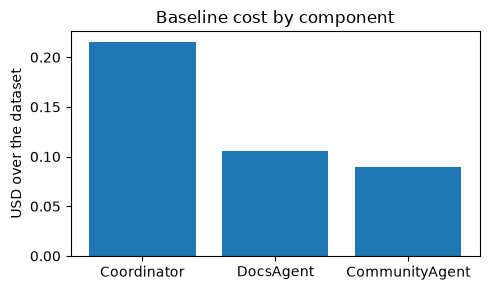

,query_id,agent,call_type,input_tokens,cached_tokens,output_tokens,thought_tokens,retrieval_queries,embed_tokens,cost_usd
0,t1,Coordinator,model,163,0,36,149,0,0,0.00254600
1,t1,DocsAgent,model,99,0,19,54,0,0,0.00080550
2,t1,DocsAgent,retrieval,0,0,0,0,1,0,0.00150000
3,t1,CommunityAgent,model,99,0,21,44,0,0,0.00073350
4,t1,CommunityAgent,embedding,0,0,0,0,0,5,0.00000075
...,...,...,...,...,...,...,...,...,...,...
117,t15,CommunityAgent,model,103,0,22,67,0,0,0.00095550
118,t15,CommunityAgent,embedding,0,0,0,0,0,6,0.00000090
119,t15,CommunityAgent,model,392,0,416,135,0,0,0.00554700
120,t15,DocsAgent,model,375,0,483,390,0,0,0.00841950


In [ ]:
# Measures all 15 dataset queries, then scores their quality. Takes about 8 minutes.
import matplotlib.pyplot as plt
coord, ledger = build(MODELS)
row, _ = measure(coordinator=coord, items=dataset, qid_holder=qid, ledger=ledger,
                 project=PROJECT, location=EVAL_LOCATION, label="baseline (Pro coordinator)")
record_result(row)
show_result(row["configuration"], row["cost_per_query"], row["quality"])

bd = row["breakdown"]
plt.figure(figsize=(5, 3)); plt.bar(list(bd.keys()), list(bd.values()))
plt.ylabel("USD over the dataset"); plt.title("Baseline cost by component"); plt.tight_layout(); plt.show()

# The full ledger behind those numbers: one row per billable event across all 15 queries.
ledger.to_df()[["query_id", "agent", "call_type", "input_tokens", "cached_tokens",
                "output_tokens", "thought_tokens", "retrieval_queries", "embed_tokens", "cost_usd"]]

#### What you should see

A cost per query of a few cents, quality around 0.9 (the reference-anchored judge rarely awards a
perfect score), and a component chart dominated by the Coordinator. Check
your prediction: the Coordinator's Pro-priced synthesis, thought tokens included, usually dominates
the bill. In the full ledger table, look at
the Coordinator's `thought_tokens`: at HIGH thinking it bills hundreds of thought tokens per query at
the $12/1M output rate, a large slice of its bill. That reasoning spend is a dial we will turn in
Part 4. This is the reference point every configuration gets compared against.

## Part 2: Model selection & tiering (lever 1)

The coordinator doesn't always need Gemini Pro. Model families come in tiers (Pro, Flash, Flash-Lite), each
cheaper per token. To compare models fairly, everything else should stay fixed: same sub-agents, same
retrieval, and the same **HIGH thinking effort**; you change only the coordinator's model. Move down one tier
at a time and re-measure **both axes** each time.

In [14]:
# Takes about 7 minutes.

# ---- LEVER 1, step 1: tier the coordinator from Pro to Flash (thinking stays HIGH) ----
TIERED_MODELS = {**MODELS, "coordinator": "gemini-3.5-flash"}   # was: gemini-3.1-pro-preview
# -----------------------------------------------------------------------------------------

coord, ledger = build(TIERED_MODELS)
row, _ = measure(coordinator=coord, items=dataset, qid_holder=qid, ledger=ledger,
                 project=PROJECT, location=EVAL_LOCATION, label="lever 1a: tiering (Flash @ HIGH)")
record_result(row)
show_result(row["configuration"], row["cost_per_query"], row["quality"])

# Where the spend sits now, per agent:
ledger.to_df().groupby("agent")[["input_tokens", "thought_tokens", "output_tokens", "cost_usd"]].sum()

lever 1a: tiering (Flash @ HIGH):   0%|          | 0/15 [00:00<?, ?query/s]

Scoring 15 answers with the LLM judge (about 1 minute)...
Computing metrics with a total of 15 Vertex Gen AI Evaluation Service API requests.


100%|██████████| 15/15 [01:54<00:00,  7.63s/it]

All 15 metric requests are successfully computed.
Evaluation Took:114.43899915199972 seconds


Judge done in 114s


,input_tokens,thought_tokens,output_tokens,cost_usd
agent,,,,
CommunityAgent,7483,3232,5522,0.09003375
Coordinator,22482,6326,7728,0.16020900
DocsAgent,4048,1538,2360,0.05465400


#### What you should see

Cost per query roughly 25 to 40% below the baseline, with quality staying within the judge's
run-to-run variance of the baseline.
This is a genuinely fair comparison: the same HIGH thinking effort on a cheaper model. The per-agent
table shows the double mechanism: Flash's tokens cost less **and** it spends fewer thought tokens on
the same work. This step is the (near) free win.

**Step 2: one tier further, and a trap.** Flash held quality at a lower price. Is Flash-Lite,
6x cheaper per token than Flash, cheaper still? Re-measure and watch closely: this step is the
lab's cautionary tale. (If a tool call does not parse cleanly, you will see a one-line notice; the query retries once, and only a query that fails twice stops the run.)

In [15]:
# Takes 5 to 12 minutes; run-to-run cost varies widely for this configuration; the section below explains why.

# ---- LEVER 1, step 2: tier the coordinator to Flash-Lite (thinking stays HIGH) ----
LITE_MODELS = {**MODELS, "coordinator": "gemini-3.1-flash-lite"}   # was: gemini-3.5-flash
# -------------------------------------------------------------------------------------

coord, ledger = build(LITE_MODELS)
row, _ = measure(coordinator=coord, items=dataset, qid_holder=qid, ledger=ledger,
                 project=PROJECT, location=EVAL_LOCATION, label="lever 1b: tiering (Flash-Lite @ HIGH)")
record_result(row)
show_result(row["configuration"], row["cost_per_query"], row["quality"])

# Where the spend sits now, per agent:
ledger.to_df().groupby("agent")[["input_tokens", "thought_tokens", "output_tokens", "cost_usd"]].sum()

lever 1b: tiering (Flash-Lite @ HIGH):   0%|          | 0/15 [00:00<?, ?query/s]

Scoring 15 answers with the LLM judge (about 1 minute)...
Computing metrics with a total of 15 Vertex Gen AI Evaluation Service API requests.


100%|██████████| 15/15 [00:24<00:00,  1.65s/it]

All 15 metric requests are successfully computed.
Evaluation Took:24.701753728999847 seconds


Judge done in 25s


,input_tokens,thought_tokens,output_tokens,cost_usd
agent,,,,
CommunityAgent,5833,2852,4615,0.07596900
Coordinator,22142,14389,6577,0.03698450
DocsAgent,10717,3524,3449,0.10733250


#### What you should see

The lesson here is variability. Maximum reasoning effort on a compact model produces widely varying
spend on this workload: during calibration this exact configuration measured anywhere from a third
of the baseline to nearly double it (\\$0.007 to \\$0.048 per query), with quality moving too. The
point is not the model; it is the pairing: this combination of model size and reasoning effort does
not fit the task, and a configuration whose cost you cannot predict is its own kind of expensive.
Right-sizing both choices is exactly where Part 4 goes.

One more calibration measurement: the previous-generation `gemini-3-flash-preview`
scored the same quality as 3.5 Flash here but cost about the same per query despite 3x cheaper rates,
because it spends roughly 3x the tokens. **Per-token price is not per-query cost; measure, do not
assume.**

## Part 3: Context caching (lever 2)

Many production agents send a large, stable prefix on every call: a long system prompt, a product
manual, few-shot examples, detailed tool instructions. Cache that prefix once and it bills at the **cached**
rate, one-tenth the input rate, on every later call. Our Code Assistant Agent's own prefix is only about 150
tokens, well under the 4,096-token minimum a cache will accept, so this part demonstrates the mechanism on a
deliberately large **substitute prefix** (one sentence repeated 700 times, about 8,400 tokens). Caching
acts on *input* cost only, so we compare the **input portion** of the bill (output and thought tokens
vary run to run).

One subtlety: Gemini also caches repeated prefixes **implicitly** on its own, so a naive A/B against a
second live "no cache" request can understate the saving (the comparison call may get a hidden discount).
We therefore derive the no-cache comparator from the cached call's own token counts.

In [16]:
# Takes about 30 seconds.
from google import genai
from google.genai import types

client = genai.Client(vertexai=True, project=PROJECT, location=LOCATION,
                      http_options=types.HttpOptions(retry_options=types.HttpRetryOptions()))
big_prefix = ("You are Code Assistant Agent. Standing instructions and product manual. " * 700)
# ---- LEVER 2: cache the stable prefix once, then reference it per call ------
cache = client.caches.create(model="gemini-3.5-flash",
            config=types.CreateCachedContentConfig(system_instruction=big_prefix, ttl="120s"))

# The change on each request: pass cached_content instead of resending big_prefix.
r = client.models.generate_content(model="gemini-3.5-flash", contents="Name your role in 5 words.",
        config=types.GenerateContentConfig(cached_content=cache.name))
# ------------------------------------------------------------------------------
client.caches.delete(name=cache.name)

p = PRICING["gemini-3.5-flash"]
prompt = r.usage_metadata.prompt_token_count or 0
cached = r.usage_metadata.cached_content_token_count or 0
with_cache    = ((prompt - cached) * p["input"] + cached * p["cached"]) / 1e6  # fresh @ input, prefix @ cached
without_cache = prompt * p["input"] / 1e6                                       # every token @ the input rate
print("prompt tokens: %d, served from cache: %d" % (prompt, cached))
print("input cost: without cache $%.6f  ->  with cache $%.6f  (%.0f%% cheaper)" %
      (without_cache, with_cache, 100 * (without_cache - with_cache) / without_cache))

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


prompt tokens: 8409, served from cache: 8402
input cost: without cache $0.012613  ->  with cache $0.001271  (90% cheaper)


#### What you should see

About 90% off the input portion for the cached prefix; that is the published cached rate doing the
work. Two caveats to carry forward: the discount touches only input tokens, and an explicit cache
needs a large stable prefix (4,096 tokens minimum for Gemini 3 family models) before it can even be
created, which is why this
demo uses an artificially large one. Where a workload qualifies, the savings stack on any
configuration you choose.

## Part 4: Reasoning & retrieval token reduction (lever 3)

Two dials, turned one at a time on the Flash-tiered configuration from Part 2. Step A turns down the
**thinking level**: reasoning ("thought") tokens cost the same as output tokens, so they are a direct
spend dial. Step B trims **retrieval breadth** (`top_k`). A third, blunter dial exists, a hard cap on
output tokens; it starves the answer when the cap is smaller than the thinking plus the answer the model would
naturally produce (thinking spends from the same budget first), so it is deliberately left out of
this part. You will meet it as a final-challenge knob.

In [17]:
# Takes about 5 minutes.

# ---- LEVER 3, step A: turn the thinking dial down on the Flash coordinator ----
THINKING_LOW = "LOW"   # was: "HIGH"
# ---------------------------------------------------------------------------------

coord, ledger = build(TIERED_MODELS, thinking_level=THINKING_LOW)
row, _ = measure(coordinator=coord, items=dataset, qid_holder=qid, ledger=ledger,
                 project=PROJECT, location=EVAL_LOCATION, label="lever 3a: thinking LOW (Flash)")
record_result(row)
show_result(row["configuration"], row["cost_per_query"], row["quality"])

# Where the spend sits now, per agent:
ledger.to_df().groupby("agent")[["input_tokens", "thought_tokens", "output_tokens", "cost_usd"]].sum()

lever 3a: thinking LOW (Flash):   0%|          | 0/15 [00:00<?, ?query/s]

Scoring 15 answers with the LLM judge (about 1 minute)...
Computing metrics with a total of 15 Vertex Gen AI Evaluation Service API requests.


100%|██████████| 15/15 [00:20<00:00,  1.35s/it]

All 15 metric requests are successfully computed.
Evaluation Took:20.278129138000168 seconds


Judge done in 20s


,input_tokens,thought_tokens,output_tokens,cost_usd
agent,,,,
CommunityAgent,4911,2201,3658,0.06011280
Coordinator,10858,1845,6866,0.09468600
DocsAgent,2170,942,1103,0.02916000


#### What you should see

A further cost drop of roughly 15 to 35% below the Flash @ HIGH step, with quality typically inside
the judge's run-to-run variance: on this workload, most answers do not need deep reasoning, so the thinking spend
was largely overhead. Watch the Coordinator's `thought_tokens` collapse in the per-agent table. On
harder workloads this dial does trade quality; that is why it is a dial and not a default.

**Step B: trim retrieval breadth.** `top_k` sets how many best-matching snippets each retrieval
lookup returns (this retrieval `top_k` is a parameter of our lookup function, unrelated to the
deprecated sampling parameter of the same name): DocsAgent asks Agent Search for its top `top_k`
documents, CommunityAgent asks the vector store for its top `top_k` posts, and whatever comes back
is pasted into that sub-agent's prompt as grounding context. More snippets mean more input tokens
and more material to ground on; fewer mean leaner prompts and slightly shorter answers feeding the
Coordinator, with less context available to the sub-agent. Note what it does **not** change: each
lookup still pays one flat Agent Search query fee and one embedding call, regardless of how many
snippets come back.

In [18]:
# Takes about 5 minutes.

# ---- LEVER 3, step B (stacked on step A): trim retrieval breadth ----
TOP_K = 2   # was: 3 snippets per lookup
# ----------------------------------------------------------------------

coord, ledger = build(TIERED_MODELS, thinking_level=THINKING_LOW, top_k=TOP_K)
row, _ = measure(coordinator=coord, items=dataset, qid_holder=qid, ledger=ledger,
                 project=PROJECT, location=EVAL_LOCATION, label="lever 3b: thinking LOW + top_k 2")
record_result(row)
show_result(row["configuration"], row["cost_per_query"], row["quality"])

# Where the spend sits now, per agent:
ledger.to_df().groupby("agent")[["input_tokens", "thought_tokens", "output_tokens", "cost_usd"]].sum()

lever 3b: thinking LOW + top_k 2:   0%|          | 0/15 [00:00<?, ?query/s]

Scoring 15 answers with the LLM judge (about 1 minute)...
Computing metrics with a total of 15 Vertex Gen AI Evaluation Service API requests.


100%|██████████| 15/15 [00:31<00:00,  2.10s/it]

All 15 metric requests are successfully computed.
Evaluation Took:31.455112880000343 seconds


Judge done in 31s


,input_tokens,thought_tokens,output_tokens,cost_usd
agent,,,,
CommunityAgent,3498,1383,2759,0.04253730
Coordinator,10675,2296,6312,0.09348450
DocsAgent,2891,1044,1780,0.04025250


#### What you should see

A small additional trim at best: input tokens are the cheap dimension at Flash rates, and the
per-call retrieval fees do not scale with `top_k`. Expect the scorecard to show this step close to
step A, occasionally indistinguishable from it. That is a result too: knowing which knobs are minor
is part of knowing where the money goes.

## Part 5: Compare the configurations

You have now measured five configurations: the baseline, two tiering steps at pinned HIGH
thinking (lever 1a: Flash, lever 1b: Flash-Lite), and the two lever-3 steps (3a: thinking LOW,
3b: plus a retrieval trim). This part puts them side by side to answer the lab's central question: which
configuration gives acceptable quality at the lowest cost?

Re-running any measurement cell above updates its row on the scorecard rather than adding a
duplicate, so you can iterate freely and this comparison stays clean.

Two views of the same scorecard:

- a table with cost per query and quality, plus each configuration's cost and quality deltas
  vs the baseline
- a scatter of cost against quality; up and to the left is better, and a configuration is a poor
  choice if another one sits above and to its left

Why is caching (lever 2) not a row? Two reasons, and both are lessons. First, Part 3 measured it in
isolation rather than through the agent. Second, this agent's real stable prefix (about 150
instruction tokens) is far below the context-cache minimum, so caching does not apply to it. Caching
pays where a large prompt prefix repeats (long system prompts, manuals, few-shot examples, and
multi-turn agent trajectories); where it applies, its discount stacks on whichever configuration you
choose.

,configuration,cost_per_query,quality,cost_vs_baseline,quality_vs_baseline
0,baseline (Pro coordinator),0.02737681,0.92860000,+0%,+0.00
1,lever 1a: tiering (Flash @ HIGH),0.02032645,0.90000000,-26%,-0.03
2,lever 1b: tiering (Flash-Lite @ HIGH),0.01468573,0.91670000,-46%,-0.01
3,lever 3a: thinking LOW (Flash),0.01226392,0.95000000,-55%,+0.02
4,lever 3b: thinking LOW + top_k 2,0.01175162,0.95000000,-57%,+0.02


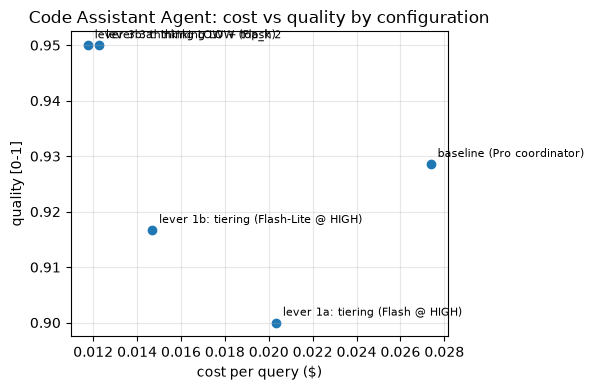

In [19]:
import pandas as pd
df = pd.DataFrame([{"configuration": r["configuration"], "cost_per_query": r["cost_per_query"], "quality": r["quality"]}
                   for r in scorecard])
base = df[df["configuration"] == "baseline (Pro coordinator)"].iloc[0]
base_cost, base_quality = base["cost_per_query"], base["quality"]
df["cost_vs_baseline"]    = (df["cost_per_query"] / base_cost - 1).map(lambda x: f"{x*100:+.0f}%")
df["quality_vs_baseline"] = (df["quality"] - base_quality).map(lambda x: f"{x:+.2f}")
display(df)

plt.figure(figsize=(6, 4)); plt.scatter(df["cost_per_query"], df["quality"])
for _, rr in df.iterrows():
    plt.annotate(rr["configuration"], (rr["cost_per_query"], rr["quality"]), fontsize=8,
                 xytext=(5, 5), textcoords="offset points")
plt.xlabel("cost per query ($)"); plt.ylabel("quality [0-1]")
plt.title("Code Assistant Agent: cost vs quality by configuration"); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### Where did the savings come from?

Cost per component, per version. Tiering shrinks the Coordinator's bar; the token-reduction levers
trim reasoning and retrieval spend, though reasoning (thought) token variance can mask its effect
run to run. Retrieval and embeddings barely change across configurations: the per-query fee is flat
and embedding spend tracks query length.

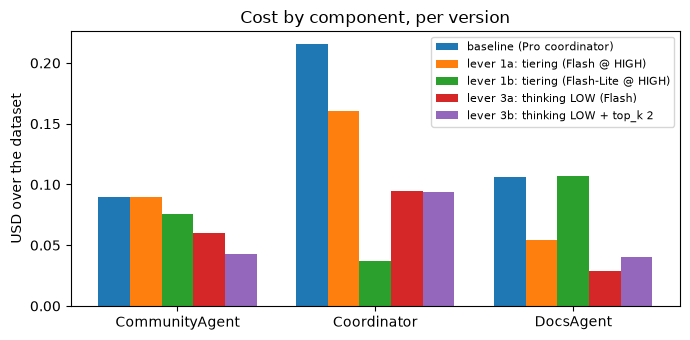

In [20]:
comps = sorted({k for r in scorecard for k in r["breakdown"]})
w = 0.8 / len(scorecard)
plt.figure(figsize=(7, 3.5))
for i, r in enumerate(scorecard):
    plt.bar([x + i*w for x in range(len(comps))],
            [r["breakdown"].get(c, 0.0) for c in comps], width=w, label=r["configuration"])
plt.xticks([x + w*(len(scorecard)-1)/2 for x in range(len(comps))], comps)
plt.ylabel("USD over the dataset"); plt.title("Cost by component, per version")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

### Bonus: a semantic response cache

In production, user queries often get repeated: the same errors and the same how-to questions
arrive again and again, phrased slightly differently. Every repeat currently pays for the full
multi-agent pipeline. The simplest defense is an **exact-match cache**: hash the full prompt and
return the stored answer when the identical prompt arrives again. No embeddings, no false hits; it
just cannot see that two phrasings mean the same thing. A **semantic response cache** generalizes
it: it stores answered questions, and when a new query arrives it checks whether the query *means*
the same thing as one already answered. The two combine naturally: check the hash first, then the
similarity.

The mechanism, step by step (see the diagram below):

1. **Embed** the incoming query. An embedding is a vector that captures the query's meaning; it bills
   per input token, a tiny fraction of a cent.
2. **Compare** it against the embeddings of stored questions using cosine similarity. An exact-match
   cache would treat "fixing a KeyError when reading a dict" and "How do I fix a KeyError in a Python
   dict?" as different; comparing meaning catches the repeat.
3. **Cache hit**: similarity is at or above the threshold, so return the stored answer. You paid for
   one embedding call instead of the whole pipeline, roughly four orders of magnitude cheaper.
4. **Cache miss**: nothing similar is stored, so run the real pipeline and store the new
   question-answer pair for next time.

The **similarity threshold** is the tradeoff knob: set it too loose and users receive answers to
questions they did not ask (a quality cost); too tight and only near-identical repeats hit (little saving). The cell
below builds a minimal version and probes it with a paraphrase (expect a hit) and an unrelated
question (expect a miss). The demo is standalone; wiring the cache in front of the Coordinator is a
production exercise.

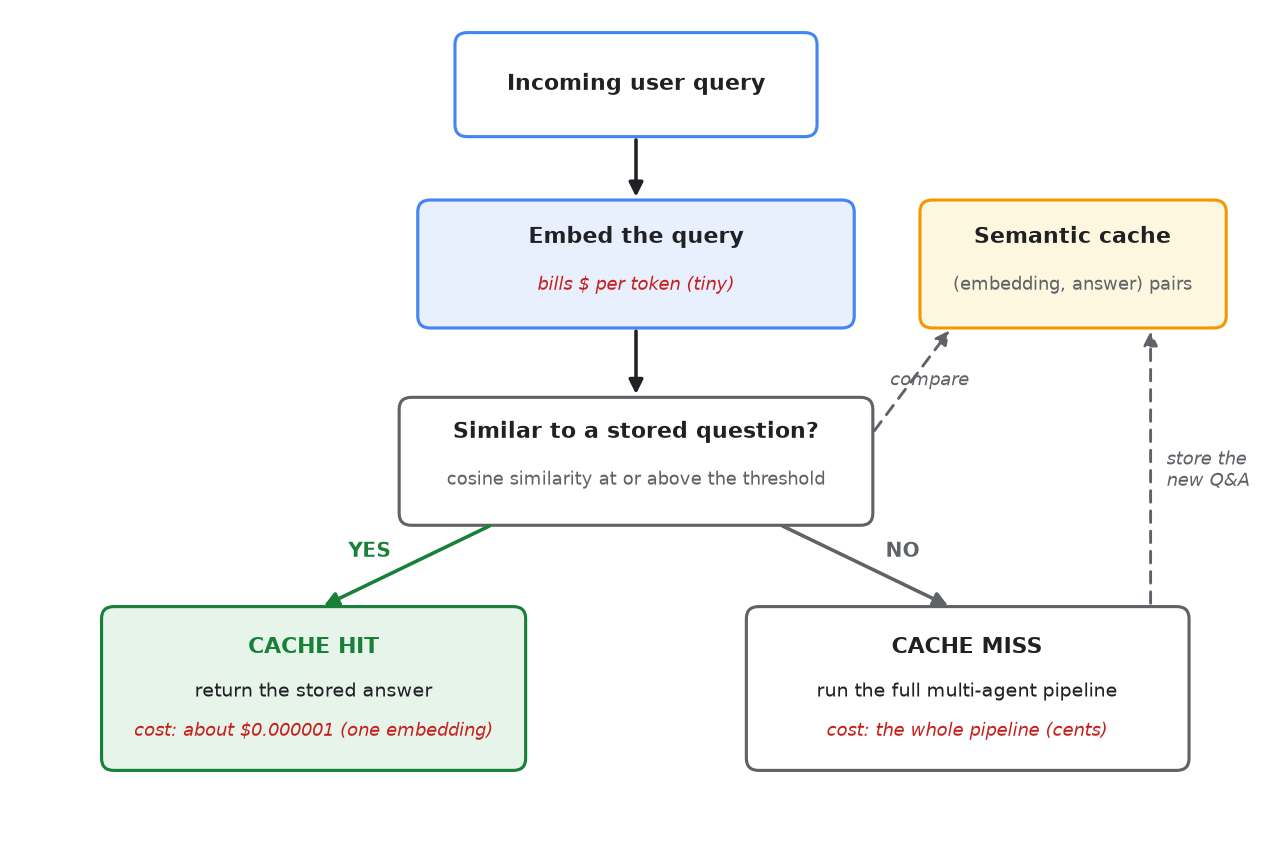

In [21]:
# The mechanism: a plain list of (embedding, answer) pairs plus a cosine-similarity lookup.
import math

class SemanticCache:
    def __init__(self, embed_fn, threshold=0.92):
        self.embed_fn = embed_fn; self.threshold = threshold
        self._entries = []; self.hits = 0; self.misses = 0
    @staticmethod
    def _cos(a, b):
        dot = sum(x*y for x, y in zip(a, b))
        na = math.sqrt(sum(x*x for x in a)); nb = math.sqrt(sum(y*y for y in b))
        return dot/(na*nb) if na and nb else 0.0
    def put(self, query, answer):
        self._entries.append((self.embed_fn(query), answer))
    def get(self, query):
        q = self.embed_fn(query); best, ans = self.threshold, None
        for emb, a in self._entries:
            s = self._cos(q, emb)
            if s >= best: best, ans = s, a
        if ans is None: self.misses += 1
        else: self.hits += 1
        return ans

**Step 1: seed the cache.** We store one already-answered question. In production the cache fills
itself, every miss runs the pipeline once and stores the new pair; here we seed a single pair by hand
to keep the demo small.

In [22]:
# Seed the cache with one answered question (embeds the question text: one API call).
_embed = lambda t: embed_texts([t], MODELS["embedding"], PROJECT, LOCATION)[0]
cache = SemanticCache(_embed, threshold=0.85)   # loosened from 0.92 so the paraphrase below can hit

seed_q, seed_a = "How do I fix a KeyError in a Python dict?", "Use dict.get(key, default)."
cache.put(seed_q, seed_a)
print("cache seeded with 1 entry:")
print("  Q:", seed_q)
print("  A:", seed_a)

cache seeded with 1 entry:
  Q: How do I fix a KeyError in a Python dict?
  A: Use dict.get(key, default).


**Step 2: probe the cache.** Now we run two new queries and see whether the cache finds a semantic
match: a paraphrase of the seeded question (different words, same meaning) and an unrelated question.

In [23]:
# Run two new queries against the cache and see if a match is found.
for q in ("fixing a KeyError when reading a dict",   # a paraphrase of the seeded question
          "how do I center a div in CSS"):           # unrelated to anything stored
    hit = cache.get(q)   # embeds q, then cosine-compares with every stored entry
    if hit:
        print("CACHE HIT : %r\n            served the stored answer %r for the cost of one embedding call" % (q, hit))
    else:
        print("CACHE MISS: %r\n            no similar entry; this query would run the full multi-agent pipeline" % q)

CACHE HIT : 'fixing a KeyError when reading a dict'
            served the stored answer 'Use dict.get(key, default).' for the cost of one embedding call
CACHE MISS: 'how do I center a div in CSS'
            no similar entry; this query would run the full multi-agent pipeline


#### What you should see

The paraphrased question returns the stored answer for the cost of one embedding call, a tiny
fraction of a full multi-agent run. The unrelated question misses and would fall through to the real
pipeline. The similarity threshold is the knob: too loose and users receive wrong cached answers (a
quality cost); too tight and only near-identical repeats hit. On repeat-heavy traffic this is often the largest
single saving available.

Now put the levers together and prove it on queries you have never optimized against.

## Part 6: Final challenge

Optimize Code Assistant Agent to meet a **cost-per-query budget** while keeping **quality at or above a
quality floor**, scored on the held-out set. The first cell below sets **your thresholds**, both fixed for this lab: a cost budget of
**$0.0135 per query** (roughly half the Part 1 reference baseline) and a quality floor of
**0.90**, displayed as the target to hit. The knobs below start **empty**: nothing is filled in, and an assert halts the cell until you set
`MY_MODELS`, `MY_THINKING`, and `MY_TOPK` (`MY_MAXOUT` is optional). Draw on what you learned in
Parts 1 to 4 to choose each value. No single lever will hit the budget, and even the straightforward combination of the taught
levers falls short; the budget rewards working out where the spend actually sits.
Re-run and repeat until the verdict turns green.

In [24]:
# Your objective: a fixed cost budget and a fixed quality floor; a PASS needs both at once.
BUDGET = 0.0135        # USD per query on the held-out set; roughly half the Part 1
                       # reference baseline (~$0.026/query), so the straightforward lever
                       # combination alone will not reach it
QUALITY_FLOOR = 0.90   # calibrated for this lab's judge and eval set; the autorater
                       # has some run-to-run variance, so a good configuration can
                       # occasionally draw just under it (see Success criteria)

def check_challenge_pass(cost_per_query, quality, *, budget, quality_floor):
    reasons = []
    if cost_per_query > budget:
        reasons.append("cost/query %.6f exceeds budget %.6f" % (cost_per_query, budget))
    if quality < quality_floor:
        reasons.append("quality %.3f below floor %.3f" % (quality, quality_floor))
    return {"passed": not reasons, "cost_per_query": cost_per_query, "quality": quality,
            "budget": budget, "quality_floor": quality_floor, "reasons": reasons}

show_target(BUDGET, QUALITY_FLOOR)

In [25]:
# Scores the 16 held-out queries; runs in about 8 minutes once the knobs are set.

# ===================================================================================================================
# [TODO: YOUR OPTIMIZATION (fill in every TODO below; the assert stops the cell until you do)]
MY_MODELS = {"coordinator": "gemini-3.5-flash",       # lever 1a: Pro -> Flash (Flash-Lite not allowed here)
             "docs":        "gemini-3.1-flash-lite",  # sub-agents only read snippets and summarize -> cheapest tier
             "community":   "gemini-3.1-flash-lite",
             "embedding":   "gemini-embedding-001"}   # must stay pinned
MY_THINKING = "LOW"  # lever 3a: thinking cost is billed at the output rate; LOW held quality in Part 4
MY_TOPK     = 3      # lever 3b: little saving at Flash-Lite rates, so keep the grounding for quality
MY_MAXOUT   = None   # keep the 3,072 ceiling; a tight cap cuts answers short

assert None not in MY_MODELS.values() and MY_THINKING and MY_TOPK, \
    "Fill in the TODO knobs above before running the final challenge (MY_MAXOUT can stay None)."
_MEASURED = {"gemini-3.1-pro-preview", "gemini-3.5-flash", "gemini-3.1-flash-lite"}
_bad = {k: m for k, m in MY_MODELS.items() if k != "embedding" and m not in _MEASURED}
assert not _bad, f"Model id(s) {_bad} are not tiers this lab measured; check the exact ids you used in Parts 1 and 2."
assert MY_MODELS["coordinator"] != "gemini-3.1-flash-lite", \
    ("Challenge rule: the Coordinator seat needs a tier you can rely on; run it on Pro or Flash. "
     "Lever 1b showed why the budget tier cannot be trusted to coordinate. Sub-agent tiers are unrestricted.")
assert "embedding" in str(MY_MODELS["embedding"]), \
    "The embedding slot needs the embedding model you used throughout this lab, not an LLM."

coord, ledger = build(MY_MODELS, thinking_level=MY_THINKING, max_output_tokens=MY_MAXOUT, top_k=MY_TOPK)
cap, _ = measure(coordinator=coord, items=holdout, qid_holder=qid, ledger=ledger,
                 project=PROJECT, location=EVAL_LOCATION, label="final challenge submission")
res = check_challenge_pass(cap["cost_per_query"], cap["quality"], budget=BUDGET, quality_floor=QUALITY_FLOOR)
show_result(cap["configuration"], cap["cost_per_query"], cap["quality"])
show_verdict(res["passed"], res["reasons"])

# Where your submission's spend sits, per agent:
ledger.to_df().groupby("agent")[["input_tokens", "thought_tokens", "output_tokens", "cost_usd"]].sum()

final challenge submission:   0%|          | 0/16 [00:00<?, ?query/s]

Scoring 16 answers with the LLM judge (about 1 minute)...
Computing metrics with a total of 16 Vertex Gen AI Evaluation Service API requests.


100%|██████████| 16/16 [01:21<00:00,  5.07s/it]

All 16 metric requests are successfully computed.
Evaluation Took:81.13944704000005 seconds


Judge done in 81s


,input_tokens,thought_tokens,output_tokens,cost_usd
agent,,,,
CommunityAgent,3852,0,4249,0.00735135
Coordinator,15710,4830,9463,0.15220200
DocsAgent,3833,0,2825,0.02019575


In [26]:
# Do not remove or modify this cell, it will be used for tracking purposes
import json
from google.cloud import storage

PROJECT_ID = !(gcloud config get-value project)
PROJECT_ID = PROJECT_ID[0]
RESULT_BUCKET = f"{PROJECT_ID}-metrics-result"

results = {
    "cost_per_query": cap['cost_per_query'],
    "quality": cap['quality'],
    "budget": BUDGET,
    "quality_floor": QUALITY_FLOOR,
    "passed": res['passed']
}

# save locally
with open("/home/jupyter/final_metrics.json", "w") as f:
    json.dump(results, f, indent=2)

# upload to GCS
client = storage.Client(project=PROJECT_ID)
bucket = client.bucket(RESULT_BUCKET)
blob = bucket.blob("results/final_metrics.json")
blob.upload_from_filename("/home/jupyter/final_metrics.json")

print(f"Uploaded to gs://{RESULT_BUCKET}/results/final_metrics.json")


Uploaded to gs://qwiklabs-gcp-04-defacf1d0ff9-metrics-result/results/final_metrics.json


#### Success criteria

PASS requires both halves at once: cost per query at or below the fixed $0.0135 budget (roughly half
the reference baseline), and quality at or above 0.90, scored on held-out queries you never
optimized against. If you fail on cost, tier a model down or turn the thinking dial lower; if you
fail on quality, raise the thinking level or restore a stronger coordinator. `MY_MAXOUT` is the
blunt tool: real savings are small and it starves the answer when the cap is smaller than the
thinking plus the answer, so reach for it last. Change the knobs, re-run the cell, and watch both
numbers move.

One honest caveat: the quality score comes from an LLM autorater, which has some run-to-run
variance. Once in a while a genuinely good configuration draws a score just under the quality floor.
If your cost is comfortably inside the budget and quality lands within a few hundredths of
0.90, re-run the cell before changing anything.

## Recap

- The **cost model** defined in this notebook, priced through the imported **usage ledger**, made
  every lever's effect measurable per query and per component.
- **Model tiering** was the biggest single win here, and it is a ladder: the Flash step held
  quality, the Flash-Lite step traded some for another large saving; **caching** cuts repeated input cost; **token
  reduction** can trim further at some cost to quality, so re-measure both sides; the **semantic cache**
  wins big on repeat traffic.
- The lowest cost is not the goal. The lowest cost **at acceptable quality** is, which is what the
  final challenge enforces.

Production notes: the lab runs the Gemini 3 family end to end (`gemini-3.1-pro-preview` coordinator,
`gemini-3.5-flash` sub-agents) on the global endpoint. The lab includes a 15-query dataset and a
16-query held-out set (easy to hard); at this size the LLM judge moves plus or minus 0.02 to 0.03 run to run
on the 0-to-1 quality score, so grow the sets if you need steadier numbers. DocsAgent runs on managed Agent Search; in
your own projects, the same pattern would index your internal docs and repositories.

## Learn more

- [Gemini model pricing](https://cloud.google.com/vertex-ai/generative-ai/pricing)
- [Context caching overview](https://cloud.google.com/vertex-ai/generative-ai/docs/context-cache/context-cache-overview)
- [Agent Development Kit (ADK) documentation](https://google.github.io/adk-docs/)
- [Gen AI evaluation service overview](https://cloud.google.com/vertex-ai/generative-ai/docs/models/evaluation-overview)
- [Agent Search pricing](https://cloud.google.com/generative-ai-app-builder/pricing)

## Optional: reset the lab

To rebuild from scratch (for example to re-test provisioning), delete the Agent Search data store
and engine with the cell below, then re-run the notebook from the top.

In [ ]:
# WARNING: deletes the managed Agent Search data store + engine for this lab.
# Uncomment and run to test the lab from scratch; the next full run re-provisions.
# vais.teardown(PROJECT, VAIS_LOCATION, DS_ID, ENGINE_ID)